In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv("/content/titanic_toy.csv")

In [6]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [12]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.2 , random_state = 2)

In [14]:
#here we ll be creating 2 new columsn
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus'] = X_train['Age'].fillna(-1)
X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus'] = X_train['Fare'].fillna(-1)

In [9]:
df.sample(5)

,Age,Fare,Family,Survived,Age_99,Age_minus,Fare_999,Fare_minus
47,NaN,7.7500,0,1,99.0,-1.0,7.7500,7.7500
281,28.0,NaN,0,0,28.0,28.0,999.0000,-1.0000
467,56.0,26.5500,0,0,56.0,56.0,26.5500,26.5500
798,30.0,7.2292,0,0,30.0,30.0,7.2292,7.2292
609,40.0,153.4625,0,1,40.0,40.0,153.4625,153.4625


In [15]:
print("orignal variance of age " , X_train['Age'].var())
print("variance of age_99 " , X_train['Age_99'].var())
print("variance of age-minus " , X_train['Age_minus'].var())

print("orignal variance of fare " , X_train['Fare'].var())
print("variance of fare_99 " , X_train['Fare_999'].var())
print("variance of fare_minus " , X_train['Fare_minus'].var())

orignal variance of age  204.3495133904614
variance of age_99  951.7275570187172
variance of age-minus  318.0896202624484
orignal variance of fare  2448.197913706318
variance of fare_99  47219.20265217623
variance of fare_minus  2378.5676784883503


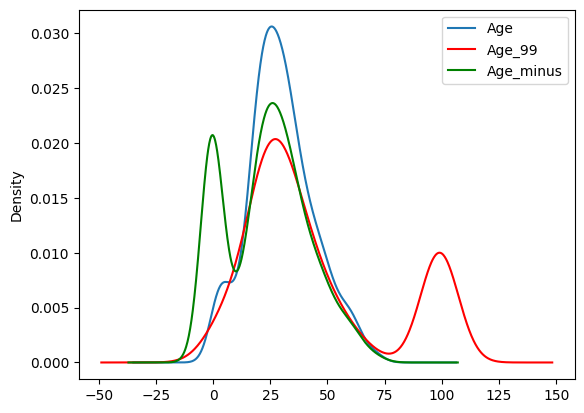

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal variable distribution
X_train['Age'].plot(kind = 'kde' , ax = ax)

X_train['Age_99'].plot(kind = 'kde' , ax = ax , color = 'red')

X_train['Age_minus'].plot(kind = 'kde' , ax = ax , color = 'green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc = 'best')

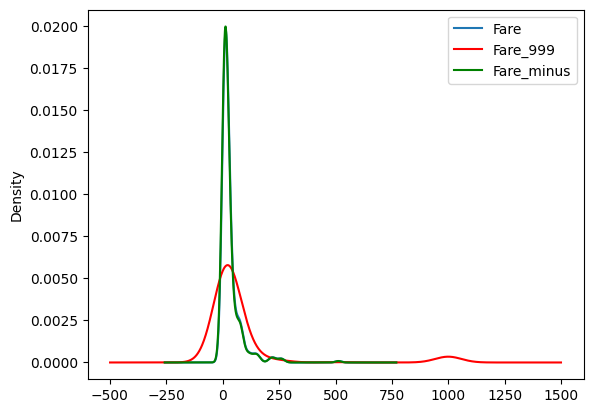

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orginal variable distribution
X_train['Fare'].plot(kind = 'kde' , ax = ax)

X_train['Fare_999'].plot(kind = 'kde' , ax = ax , color = 'red')

X_train['Fare_minus'].plot(kind = 'kde' , ax = ax , color = 'green')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc = 'best')

In [18]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus,Fare_999,Fare_minus
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [19]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus,Fare_999,Fare_minus
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


In [20]:
#USING SKLEARN FOR THE SAME
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [21]:
#imputer fills missing values with a constant fixed value , here it is 99

imputer1 = SimpleImputer(strategy = 'constant' , fill_value=99)
imputer2 = SimpleImputer(strategy = 'constant' , fill_value = 999)

In [23]:
trf = ColumnTransformer([
    ('imputer1' , imputer1,['Age']),
    ('imputer2' , imputer2,['Fare'])
], remainder = 'passthrough')

In [24]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [27]:
#it returns the value which the imouter1 is putting in missing areas
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [28]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [29]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [30]:
X_train

array([[ 40.    ,  27.7208,   0.    , ...,  40.    ,  27.7208,  27.7208],
       [  4.    ,  16.7   ,   2.    , ...,   4.    ,  16.7   ,  16.7   ],
       [ 47.    ,   9.    ,   0.    , ...,  47.    ,   9.    ,   9.    ],
       ...,
       [ 71.    ,  49.5042,   0.    , ...,  71.    ,  49.5042,  49.5042],
       [ 99.    , 221.7792,   0.    , ...,  -1.    , 221.7792, 221.7792],
       [ 99.    ,  25.925 ,   0.    , ...,  -1.    ,  25.925 ,  25.925 ]])